# Обучение EfficientNet-B0 на GTSRB

Этот блокнот демонстрирует полный цикл обучения EfficientNet-B0 
на датасете немецких дорожных знаков GTSRB.

EfficientNet-B0 использует составное масштабирование для достижения 
высокой эффективности при меньшем количестве параметров.

In [ ]:
# Импорт библиотек
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from configs.efficientnet_config import EfficientNetConfig
from src.data_loader_gpu import get_optimized_data_loaders
from src.model_efficientnet_gpu import create_efficientnet_b0_gpu
from src.train_efficientnet_gpu import EfficientNetGPUTrainer, evaluate_gpu
from src.utils import GPUManager, profile_model_performance

c:\Users\bgkru\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1. Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cpu
CUDA available: False


In [4]:
# 2. Загрузка данных
config = EfficientNetConfig
train_loader, val_loader, test_loader = get_data_loaders(config)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Classes: {config.NUM_CLASSES}")


Train samples: 31367
Val samples: 7842
Test samples: 12630
Classes: 43


Training batch with augmentations:


c:\Users\bgkru\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


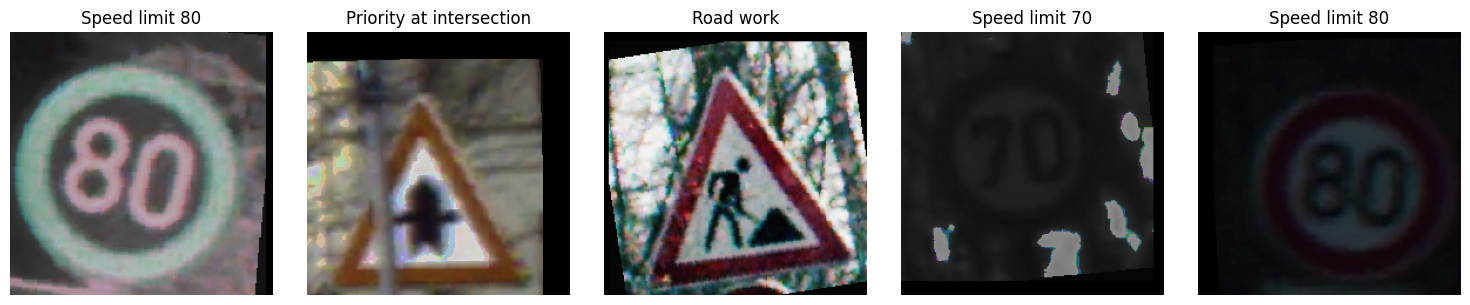

In [5]:
# 3. Визуализация данных с AutoAugment
def show_batch_with_augmentation(dataloader, class_names, n=5):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        # Денормализация
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i].item()])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

class_names = config.get_class_names()
print("Training batch with augmentations:")
show_batch_with_augmentation(train_loader, class_names)

In [ ]:
# 4. Создание модели EfficientNet-B0
model = create_efficientnet_b0(config)
model = model.to(device)

print(f"\nTotal parameters: {model.get_total_params():,}")
print(f"Trainable parameters: {model.get_trainable_params():,}")
print(f"Model size: {model.get_model_size_mb():.2f} MB")

Model: efficientnet_b0
Total parameters: 4,685,479
Trainable parameters: 4,685,479
Model size: 17.87 MB

Total parameters: 4,685,479
Trainable parameters: 4,685,479
Model size: 17.87 MB


c:\Users\bgkru\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bgkru\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


: 

In [ ]:
# 5. Обучение модели
trainer = EfficientNetTrainer(model, config, device)
history = trainer.train(train_loader, val_loader)

Starting training on cpu
Model: efficientnet_b0
Total epochs: 30
Learning rate: 0.001
Batch size: 64

Epoch [1/30]
----------------------------------------


Training:   0%|          | 0/491 [00:00<?, ?it/s]

: 

In [ ]:
# 6. Визуализация истории обучения
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(history['learning_rates'], label='Learning Rate', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_title('Learning Rate Schedule')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.plot(history['train_time'], label='Epoch Time', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Time (s)')
ax4.set_title('Training Time per Epoch')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 7. Оценка на тестовых данных
results, preds, labels = evaluate_efficientnet(model, test_loader, config, device)

print("\nTest Results:")
print(f"Accuracy: {results['accuracy']:.4f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall: {results['recall']:.4f}")
print(f"F1-Score: {results['f1_score']:.4f}")

In [ ]:
# 8. Измерение скорости инференса
avg_time, std_time = measure_inference_time(model, device)
print(f"\nInference Time: {avg_time:.2f} ± {std_time:.2f} ms")
print(f"FPS: {1000 / avg_time:.2f}")

In [ ]:
# 9. Визуализация предсказаний
# Получаем батч из тестовой выборки
test_batch = next(iter(test_loader))
images, true_labels = test_batch
images = images[:8]  # Берем 8 изображений
true_labels = true_labels[:8]

# Предсказания
model.eval()
with torch.no_grad():
    images = images.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

display_predictions(images.cpu(), preds.cpu(), true_labels.cpu(), 
                    class_names, num_examples=8)


In [ ]:

# 10. Анализ ошибок
def analyze_errors(preds, labels, class_names):
    """Анализ ошибок классификации"""
    from collections import Counter
    
    errors = []
    for i, (pred, true) in enumerate(zip(preds, labels)):
        if pred != true:
            errors.append({
                'true_class': true,
                'true_label': class_names[true],
                'pred_class': pred,
                'pred_label': class_names[pred]
            })
    
    print(f"\nTotal errors: {len(errors)} out of {len(labels)}")
    print(f"Error rate: {len(errors) / len(labels) * 100:.2f}%")
    
    # Наиболее частые ошибки
    error_types = Counter([(e['true_label'], e['pred_label']) for e in errors])
    print("\nMost common errors:")
    for (true, pred), count in error_types.most_common(10):
        print(f"  {true} -> {pred}: {count} times")
    
    return errors

errors = analyze_errors(preds, labels, class_names)


In [ ]:
# 11. Сравнение с ResNet-50
print("\n" + "=" * 60)
print("COMPARISON WITH RESNET-50")
print("=" * 60)
print(f"EfficientNet-B0 accuracy: {results['accuracy']:.4f}")
print(f"EfficientNet-B0 inference: {avg_time:.2f} ms")
print(f"EfficientNet-B0 size: {model.get_model_size_mb():.2f} MB")
print(f"EfficientNet-B0 params: {model.get_total_params():,}")
print("\n(ResNet-50 results should be loaded from previous experiment)")

In [ ]:

# 12. Сохранение модели
torch.save(model.state_dict(), config.RUNS_PATH / 'final_model.pth')
print(f"\nModel saved to: {config.RUNS_PATH / 'final_model.pth'}")